# __Proyecto - Grupo 3__
## _Aprendizaje automático y minería de datos_
### _Integrantes:_

- Anastasia Minina
- Cristhian Burbano
- Denis Chancay
- Erick Figueroa

## 1. Definición del problema
Históricamente ha existido la creencia de que las personas alcanzaban o superaban habitualmente los 100 años de edad. Sin embargo, al analizar los registros estadísticos del período 2000 a 2015, los datos demuestran una realidad diferente: la media de vida en estos quince años ha sido de 69 años, con un máximo de 89 años.

Esta discrepancia entre el imaginario de longevidad y los promedios reales plantea la necesidad de investigar: ¿Cuáles son los factores determinantes que explican que la expectativa de vida efectiva se mantenga por debajo de los 70 años en este período?


## 2. Obtención del dataset
Se encontró el dataset de esperanza de vida en la plataforma __Kaggle__ en esta dirección web: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who/data. El datset contiene datos recopilados de 15 años, entre los años 2000 al 2015 de la esperanza de vida de las personas en 193 países, mismos que fueron tomados del repositorio de datos del Observatorio Mundial de la Salud (GHO) de la Organización Mundial de la Salud (OMS).

In [ ]:
%pip install pandas
%pip install matplotlib seaborn numpy

Importamos las librerías que utilizaremos para el análisis inicial del dataset como pandas, numpy, matplotlib y seaborn. Y mendiante pandas cargamos el dataset al área de trabajo.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('C:/Cristhian Burbano/Mestría Gestion y Analitica de Datos/5 Aprendizaje automatica y mineria de datos/Proyecto/Life Expectancy Data.csv')

## 3. Exploración de datos.
Realizaremos una explorción inicial del dataset, sus dimenciones, ver sus estadísticas descriptivas, tipos de datos, correlaciones y visualizaciones.

In [39]:
print("Dimensiones: ", df.shape)

Dimensiones:  (2938, 22)


Vemos que las dimenciones del datset son de 2938 registros con 22 columnas. Además, observamos que en algunos campos tienen valores faltantes. Y los nombres de las columnas tienen espacios al incio y al final del mismo, por lo que hay que corregir eso.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [6]:
df.columns = df.columns.str.strip()
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [67]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2007.52,4.61,2000.00,2004.00,2008.00,2012.00,2.015000e+03
Life expectancy,2928.0,69.22,9.52,36.30,63.10,72.10,75.70,8.900000e+01
Adult Mortality,2928.0,164.80,124.29,1.00,74.00,144.00,228.00,7.230000e+02
infant deaths,2938.0,30.30,117.93,0.00,0.00,3.00,22.00,1.800000e+03
Alcohol,2744.0,4.60,4.05,0.01,0.88,3.76,7.70,1.787000e+01
percentage expenditure,2938.0,738.25,1987.91,0.00,4.69,64.91,441.53,1.947991e+04
Hepatitis B,2385.0,80.94,25.07,1.00,77.00,92.00,97.00,9.900000e+01
Measles,2938.0,2419.59,11467.27,0.00,0.00,17.00,360.25,2.121830e+05
BMI,2904.0,38.32,20.04,1.00,19.30,43.50,56.20,8.730000e+01
under-five deaths,2938.0,42.04,160.45,0.00,0.00,4.00,28.00,2.500000e+03


In [42]:
df.describe(include=['object', 'category', 'str'])

,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


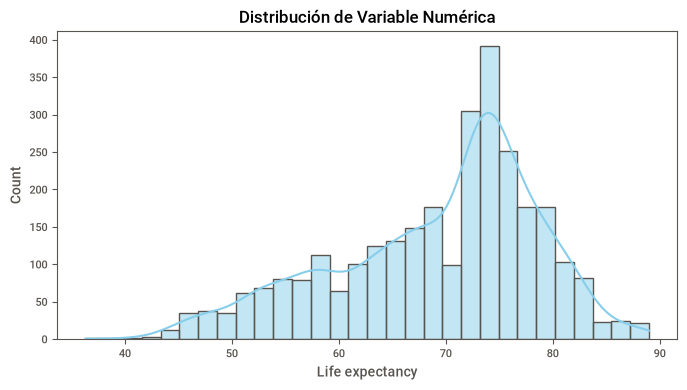

In [38]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Life expectancy', kde=True, color='skyblue')
plt.title('Distribución de Variable Numérica')
plt.show()

2026-09-11 19:17:55,706 - WARNING  - findfont: Failed to find font weight normal for Roboto, now using 500.


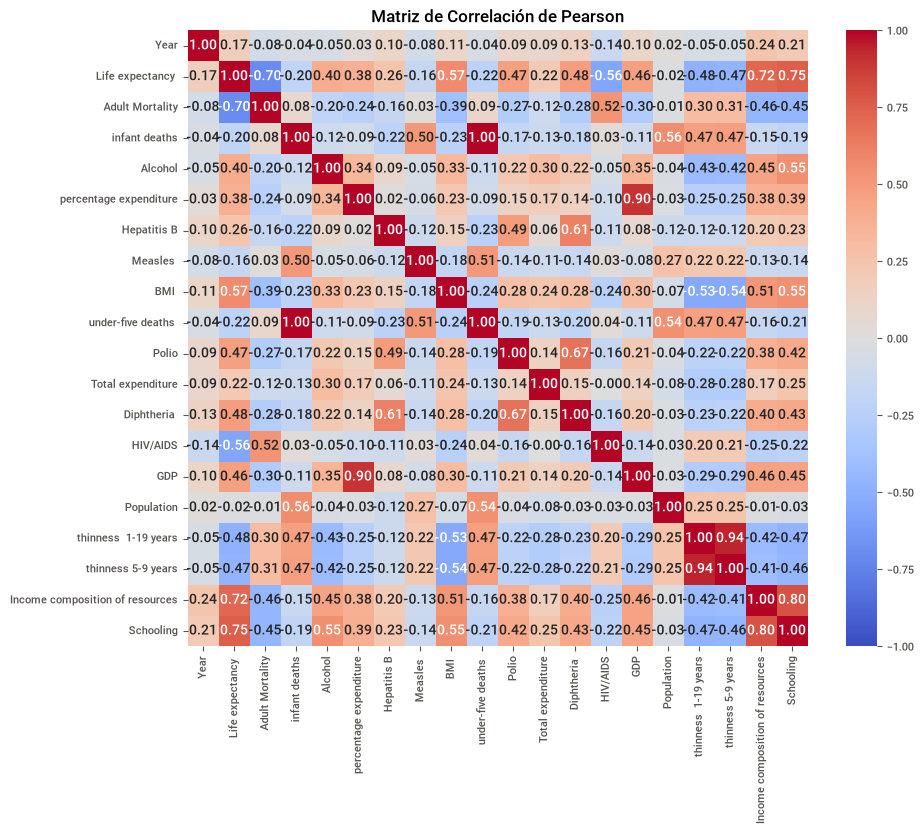

2026-09-11 19:32:44,139 - INFO     - Executing shutdown due to inactivity...
2026-09-11 19:32:56,444 - INFO     - Executing shutdown...
2026-09-11 19:32:56,459 - INFO     - Not running with the Werkzeug Server, exiting by searching gc for BaseWSGIServer


In [31]:
%matplotlib inline
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Pearson')
plt.show()

In [ ]:
#%pip install sweetviz
import sweetviz as sv
report = sv.analyze(df)
report.show_html('reporte_eda.html')

## 4. Preparación de datos
En esta sección realizaremos el proceso de calidad de datos. Generamos un conteo de valores faltantes y su respectivo porcentaje.

In [64]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

In [52]:
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
porcentaje_nulos = porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False).round(2)

print("Porcentaje de valores nulos por columna:")
print(porcentaje_nulos)

Porcentaje de valores nulos por columna:
Population                         22.19
Hepatitis B                        18.82
GDP                                15.25
Total expenditure                   7.69
Alcohol                             6.60
Income composition of resources     5.68
Schooling                           5.55
thinness 5-9 years                  1.16
thinness  1-19 years                1.16
BMI                                 1.16
Polio                               0.65
Diphtheria                          0.65
Life expectancy                     0.34
Adult Mortality                     0.34
dtype: float64


In [54]:
print(f"El porcentaje de nulos por filas: {(((df.isna().any(axis=1).sum()) / len(df)) * 100).round(2)}%")

El porcentaje de nulos por filas: 43.87%


In [47]:
print("Valores duplicados: ", df.duplicated().sum())

Valores duplicados:  0


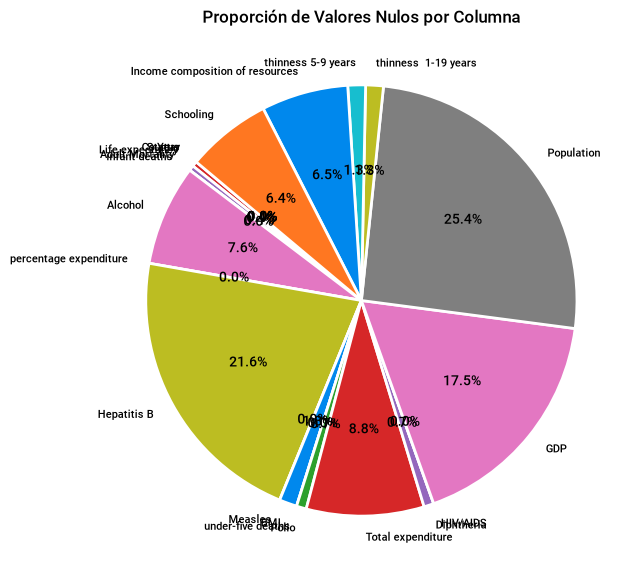

In [ ]:
nulos = df.isnull().sum()
plt.figure(figsize=(7, 7))
plt.pie(#Generar el gráfico de pastel con porcentajes
    nulos,
    labels=nulos.index, #Nombres de las columnas
    autopct="%1.1f%%", #Muestra solo el porcentaje
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2})
plt.title("Proporción de Valores Nulos por Columna", fontsize=12, fontweight="bold")
plt.show()

Acorde a la matriz de correlación y debido a que la disperción de datos, se optó por escoger las columnas mejor correlacionadas con Life expectancy, solamente las que tienen una correlación mayor al 40%, se estableció este porcentaje mínimo ya que la mayoría tiene un valor bajo e inclusive, existen correlaciones negativas.

In [22]:
colums_relevantes = ['Country', 'Year', 'Status', 'Life expectancy', 'Schooling', 'Income composition of resources',
                     'BMI',  'Diphtheria', 'Polio', 'GDP', 'Alcohol']
df_relevante = df[colums_relevantes]

Como vimos en el mapa de correlación, los valores de cada columna están muy dispersos y su correlación entre sí es muy baja. También, el porcentaje de valores faltantes es alto en algunas columnas y por el total del dataset; no se puede realizar una eliminacion de estos de manera simple, ni imputarlos normalmente ya que algunos son datos médicos estadísticos. Debido a esto decidimos dividir el dataset en 2 partes; una tendra información relacionada entre la esperanza de vida con datos de salud, y el otro, relacionado con datos socioeconómicos.

In [23]:
grupo_salud = ['Country', 'Year', 'Status', 'Life expectancy','BMI', 'Diphtheria', 'Polio', 'Alcohol']
df_grupo_salud = df_relevante[grupo_salud]
grupo_socioeconomico = ['Country', 'Year', 'Status', 'Life expectancy', 'Schooling', 
                        'Income composition of resources', 'GDP']
df_grupo_socioeconomico = df_relevante[grupo_socioeconomico]

Observamos ahora los valores nulos presentes en cada grupo, siendo estos que ahora cambian su cantidad y porcentaje.

In [25]:
nulos_grupo_salud = df_grupo_salud[df_grupo_salud.isna().any(axis=1)].shape[0]
porcentaje_nulos_grupo_salud = (nulos_grupo_salud / len(df_grupo_salud)) * 100
print("El grupo de salud tiene", nulos_grupo_salud , "nulos de", len(df_grupo_salud), "de registros, represetando un porcentaje del", porcentaje_nulos_grupo_salud)

El grupo de salud tiene 225 nulos de 2938 de registros, represetando un porcentaje del 7.658270932607215


In [26]:
nulos_grupo_socioeconomico = df_grupo_socioeconomico[df_grupo_socioeconomico.isna().any(axis=1)].shape[0]
porcentaje_nulos_grupo_socioeconmico= (nulos_grupo_socioeconomico / len(df_grupo_socioeconomico)) * 100
print("El grupo socio economico tiene", nulos_grupo_socioeconomico , "nulos de", len(df_grupo_socioeconomico), "de registros, represetando un porcentaje del", porcentaje_nulos_grupo_socioeconmico)

El grupo socio economico tiene 456 nulos de 2938 de registros, represetando un porcentaje del 15.520762423417292


Para el dataset del grupo de salud, se optó por eliminar los registros nulos, debido que la información médica son datos que no se pueden imputar ya que no serían reales a cada persona.

In [27]:
df_grupo_salud_dropna = df_grupo_salud.dropna()
#df_grupo_socioeconomico_dropna = df_grupo_socioeconomico.dropna()
df_grupo_salud_dropna.shape

(2713, 8)

En los datos del grupo socioeconómico se realizará imputación de datos mediante la mediana, pero; en primer lugar se eliminará los nulos de la columna 'Life expectancy' que es nuestra variale objetivo y del resto de campos se realizará la imputación.

In [28]:
from sklearn.impute import SimpleImputer
# Elimina filas solo si tienen nulos en 'Life expectancy'
df_grupo_socioeconomico_dropna = df_grupo_socioeconomico.dropna(subset=['Life expectancy'])
df_grupo_socioeconomico_imputer = df_grupo_socioeconomico_dropna.copy()
columnas = ['GDP', 'Schooling', 'Income composition of resources'] 
imputer = SimpleImputer(strategy="median")
for col in columnas:
  df_grupo_socioeconomico_imputer[col] = imputer.fit_transform(df_grupo_socioeconomico_imputer[[col]])

In [29]:
df_grupo_socioeconomico_imputer.info()

<class 'pandas.DataFrame'>
Index: 2928 entries, 0 to 2937
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2928 non-null   str    
 1   Year                             2928 non-null   int64  
 2   Status                           2928 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Schooling                        2928 non-null   float64
 5   Income composition of resources  2928 non-null   float64
 6   GDP                              2928 non-null   float64
dtypes: float64(4), int64(1), str(2)
memory usage: 183.0 KB


## 5. Selección y entrenamiento del modelo
Para resolver nuestro problema, hemos seleccionado un modelo de regresión lineal multiple para obtener nuestra variable objetivo.

In [ ]:
# carga de librerías
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, classification_report)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

Elaboración de los modelos para el grupo de datos de salud

In [ ]:
print("ENTRENAMIENTO Y EVALUACIÓN: GRUPO SALUD")

# 1. quitar columnas no necesarios
columnas_a_quitar = ['Country', 'Year', 'Status', 'Life expectancy']
X_salud = df_grupo_salud_dropna.drop(columns=columnas_a_quitar)
y_salud = df_grupo_salud_dropna['Life expectancy']

# Dividimos en 80% entrenamiento (train) y 20% prueba (test)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_salud, y_salud, test_size=0.20, random_state=42)

# modelo de regresion lineal (Salud)
modelo_lin_salud = LinearRegression()
modelo_lin_salud.fit(X_train_s, y_train_s)
predicciones_lin_salud = modelo_lin_salud.predict(X_test_s)
r2_lin_salud = r2_score(y_test_s, predicciones_lin_salud)
mae_lin_salud = mean_absolute_error(y_test_s, predicciones_lin_salud)

# modelo randonforest (Salud)
modelo_rf_salud = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_salud.fit(X_train_s, y_train_s)
predicciones_rf_salud = modelo_rf_salud.predict(X_test_s)
r2_rf_salud = r2_score(y_test_s, predicciones_rf_salud)
mae_rf_salud = mean_absolute_error(y_test_s, predicciones_rf_salud)

print(f"Regresión Lineal -> R-cuadrado: {r2_lin_salud:.2f} | MAE: {mae_lin_salud:.2f} años")
print(f"Random Forest    -> R-cuadrado: {r2_rf_salud:.2f} | MAE: {mae_rf_salud:.2f} años")

--- 1. ENTRENAMIENTO Y EVALUACIÓN: GRUPO SALUD ---
Regresión Lineal -> R-cuadrado: 0.46 | MAE: 5.47 años
Random Forest    -> R-cuadrado: 0.78 | MAE: 3.27 años


Elaboración de los modelos para el grupo socioeconómico de datos

In [ ]:
print("ENTRENAMIENTO Y EVALUACIÓN: GRUPO SOCIOECONÓMICO ")

# quitar datos no necesarios
X_eco = df_grupo_socioeconomico_imputer.drop(columns=columnas_a_quitar)
y_eco = df_grupo_socioeconomico_imputer['Life expectancy']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_eco, y_eco, test_size=0.20, random_state=42)

# mode de regresionn lineal (Socioeconómico)
modelo_lin_eco = LinearRegression()
modelo_lin_eco.fit(X_train_e, y_train_e)
predicciones_lin_eco = modelo_lin_eco.predict(X_test_e)
r2_lin_eco = r2_score(y_test_e, predicciones_lin_eco)
mae_lin_eco = mean_absolute_error(y_test_e, predicciones_lin_eco)

# modelo randonforest (Socioeconómico)
modelo_rf_eco = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_eco.fit(X_train_e, y_train_e)
predicciones_rf_eco = modelo_rf_eco.predict(X_test_e)
r2_rf_eco = r2_score(y_test_e, predicciones_rf_eco)
mae_rf_eco = mean_absolute_error(y_test_e, predicciones_rf_eco)

print(f"Regresión Lineal -> R-cuadrado: {r2_lin_eco:.2f} | MAE: {mae_lin_eco:.2f} años")
print(f"Random Forest    -> R-cuadrado: {r2_rf_eco:.2f} | MAE: {mae_rf_eco:.2f} años")

--- 2. ENTRENAMIENTO Y EVALUACIÓN: GRUPO SOCIOECONÓMICO ---
Regresión Lineal -> R-cuadrado: 0.59 | MAE: 4.28 años
Random Forest    -> R-cuadrado: 0.77 | MAE: 2.99 años


Ahora observamos un gráfico compartivo de los modelos de entranamiento

COMPARACIÓN FINAL DE LOS 4 MODELOS ---


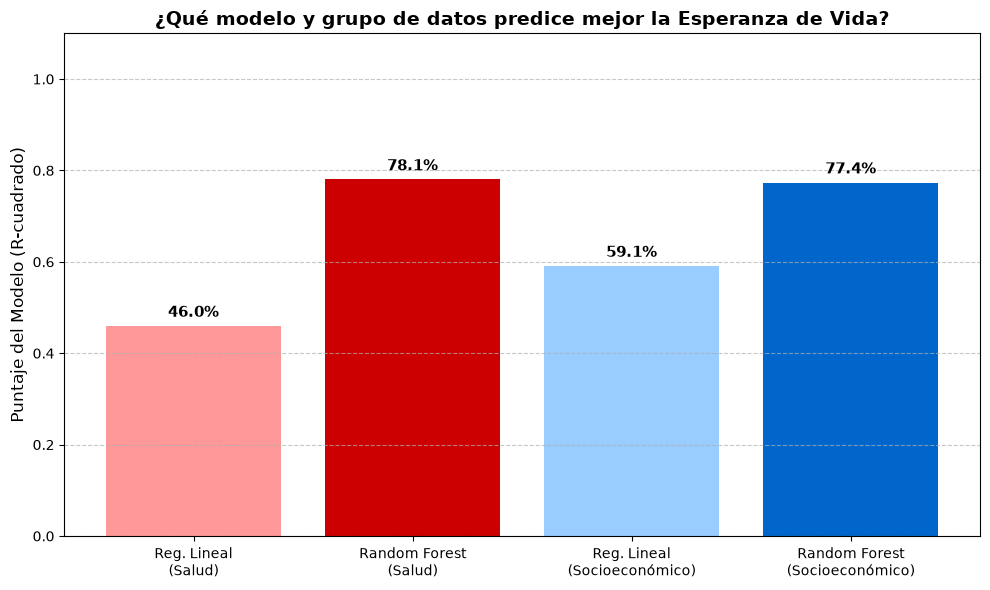

In [ ]:
print("COMPARACIÓN FINAL DE LOS 4 MODELOS")

# Preparamos los datos para el gráfico
nombres = [
    'Reg. Lineal\n(Salud)', 
    'Random Forest\n(Salud)', 
    'Reg. Lineal\n(Socioeconómico)', 
    'Random Forest\n(Socioeconómico)'
]
puntajes = [r2_lin_salud, r2_rf_salud, r2_lin_eco, r2_rf_eco]

# definimos colores
colores = ['#ff9999', '#cc0000', '#99ccff', '#0066cc']

plt.figure(figsize=(10, 6))
barras = plt.bar(nombres, puntajes, color=colores)

# añadimos los porcentajes encima de las barras
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.02, f"{yval*100:.1f}%", ha='center', fontsize=11, fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Puntaje del Modelo (R-cuadrado)', fontsize=12)
plt.title('¿Qué modelo y grupo de datos predice mejor la Esperanza de Vida?', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [51]:
## conclusion
print("\nCONCLUSIÓN:")
print("El análisis demuestra que el modelo de Random Forest utilizando variables Socioeconómicas")
print("es la herramienta más poderosa para predecir la esperanza de vida, superando a la regresión lineal y a los indicadores de salud.")


CONCLUSIÓN:
El análisis demuestra que el modelo de Random Forest utilizando variables Socioeconómicas
es la herramienta más poderosa para predecir la esperanza de vida, superando a la regresión lineal y a los indicadores de salud.


TOP PAÍSES CON MAYOR ESPERANZA DE VIDA (PREDICCIONES) ---
Calculando el ranking en base a los exámenes de los modelos...

 TOP 5 PAÍSES (Según factores de SALUD):
 - Czechia:
   Real: 77.5 años | Reg. Lineal: 80.2 | Random Forest: 82.2
 - Australia:
   Real: 82.1 años | Reg. Lineal: 78.3 | Random Forest: 82.1
 - United Kingdom of Great Britain and Northern Ireland:
   Real: 83.5 años | Reg. Lineal: 78.8 | Random Forest: 81.8
 - Greece:
   Real: 82.8 años | Reg. Lineal: 78.4 | Random Forest: 81.3
 - Malta:
   Real: 82.7 años | Reg. Lineal: 77.2 | Random Forest: 81.1

 TOP 5 PAÍSES (Según factores SOCIOECONÓMICOS):
 - Switzerland:
   Real: 82.5 años | Reg. Lineal: 82.0 | Random Forest: 83.6
 - Luxembourg:
   Real: 80.6 años | Reg. Lineal: 79.2 | Random Forest: 82.9
 - Australia:
   Real: 82.2 años | Reg. Lineal: 83.5 | Random Forest: 82.7
 - France:
   Real: 79.2 años | Reg. Lineal: 78.2 | Random Forest: 82.6
 - Sweden:
   Real: 85.2 años | Reg. Lineal: 79.4 | Random Forest: 82.4

 NOTA:

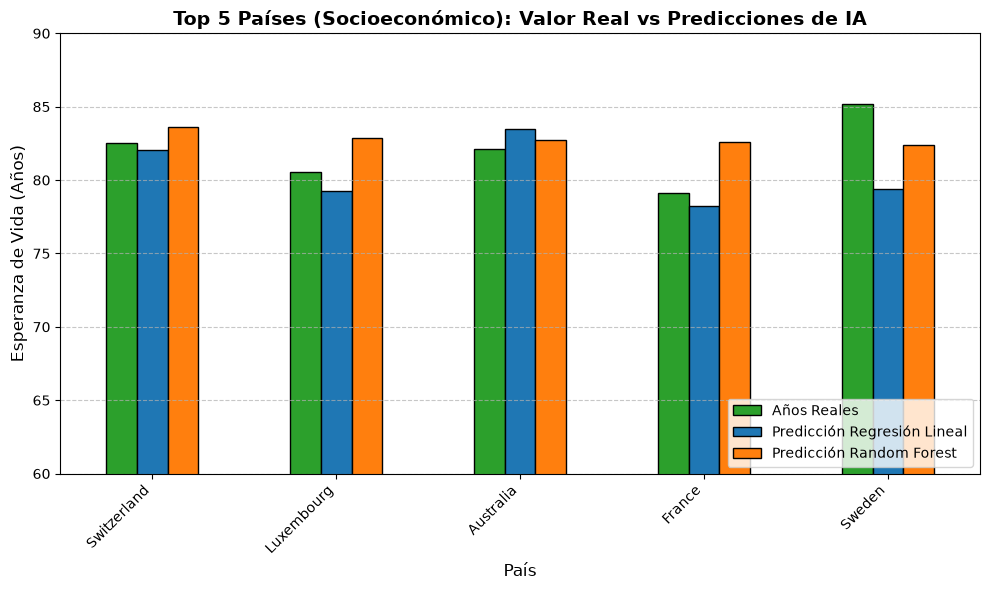

In [ ]:
print("TOP PAÍSES CON MAYOR ESPERANZA DE VIDA (PREDICCIONES) ---")
print("Calculando el ranking en base a los exámenes de los modelos...")

#grupo salud- unimos las predicciones con los nombres de los paises
df_resultados_salud = pd.DataFrame({
    'País': df_grupo_salud_dropna.loc[X_test_s.index, 'Country'],
    'Real': y_test_s,
    'Pred. Regresión Lineal': predicciones_lin_salud,
    'Pred. Random Forest': predicciones_rf_salud
})

#como un pais puede tener datos de varios años en el test, los agrupamos y sacamos el promedio
df_resultados_salud = df_resultados_salud.groupby('País').mean().reset_index()

#ordenamos de mayor a menor según el modelo Random Forest (que fue el mejor) y sacamos el Top 5
top_salud = df_resultados_salud.sort_values(by='Pred. Random Forest', ascending=False).head(5)


#grupo socioecnomico: Juntamos las predicciones con los nombres de los países
df_resultados_eco = pd.DataFrame({
    'País': df_grupo_socioeconomico_imputer.loc[X_test_e.index, 'Country'],
    'Real': y_test_e,
    'Pred. Regresión Lineal': predicciones_lin_eco,
    'Pred. Random Forest': predicciones_rf_eco
})

df_resultados_eco = df_resultados_eco.groupby('País').mean().reset_index()
top_eco = df_resultados_eco.sort_values(by='Pred. Random Forest', ascending=False).head(5)


# resultados
print("\n TOP 5 PAÍSES (Según factores de SALUD):")
#formateamos para que se vea bonito en pantalla
for i, row in top_salud.iterrows():
    print(f" - {row['País']}:")
    print(f"   Real: {row['Real']:.1f} años | Reg. Lineal: {row['Pred. Regresión Lineal']:.1f} | Random Forest: {row['Pred. Random Forest']:.1f}")

print("\n TOP 5 PAÍSES (Según factores SOCIOECONÓMICOS):")
for i, row in top_eco.iterrows():
    print(f" - {row['País']}:")
    print(f"   Real: {row['Real']:.1f} años | Reg. Lineal: {row['Pred. Regresión Lineal']:.1f} | Random Forest: {row['Pred. Random Forest']:.1f}")

print("\n NOTA: Podemos observar cómo las predicciones del Random Forest suelen acercarse más al valor Real que la Regresión Lineal.")


#garfico comparativo: real VS pedicho (GRUPO SOCIOECONÓMICO) ---
import matplotlib.pyplot as plt
import numpy as np

#tomamos los datos del Top 5 socioeconómico generado en el paso anterior
top_eco_plot = top_eco.set_index('País')[['Real', 'Pred. Regresión Lineal', 'Pred. Random Forest']]

colores = ['#2ca02c', '#1f77b4', '#ff7f0e'] # Verde (Real), Azul (Lineal), Naranja (Forest)
ax = top_eco_plot.plot(kind='bar', figsize=(10, 6), color=colores, edgecolor='black')

#detalles estéticos del gráfico
plt.title('Top 5 Países (Socioeconómico): Valor Real vs Predicciones de IA', fontsize=14, fontweight='bold')
plt.ylabel('Esperanza de Vida (Años)', fontsize=12)
plt.xlabel('País', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Años Reales', 'Predicción Regresión Lineal', 'Predicción Random Forest'], loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(60, 90) # Ajustar el eje Y para ver mejor las diferencias

#mostrar el gráfico
plt.tight_layout()
plt.show()